Listo. PNGs en: ./fig-1/build-oscar


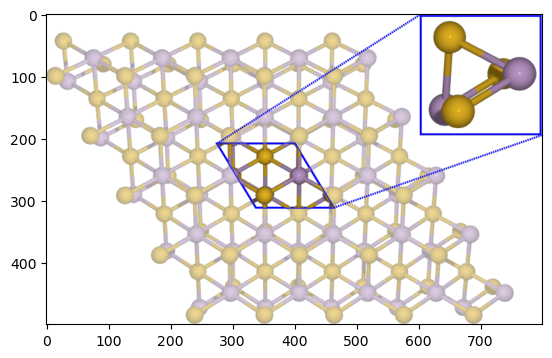

In [7]:
import numpy as np
from PIL import Image
from pdf2image import convert_from_path
import matplotlib.pyplot as plt
import glob
import re
import subprocess, os

def numkey(p):
    m = re.search(r'(\d+)(?=\D*$)', p)
    return int(m.group(1)) if m else 0

#---- 	We use ImageMagick through subprocess.
in_pdf = "./fig-1/build-oscar/Sb2Te3-sc.pdf"
out_dir = "./fig-1/build-oscar"
os.makedirs(out_dir, exist_ok=True)
out_pattern = os.path.join(out_dir, "frame_%d.png")

cmd = [
    "convert",                         
    "-density", "300",                
    "-colorspace", "sRGB",
    "-define", "pdf:use-cropbox=true",
    in_pdf,
    "-fuzz", "6%",                    
    "-transparent", "white",          
    "-trim", "+repage",              
    "-define", "png:color-type=6",    
    "-define", "png:compression-level=9",
    "-scene", "0",                    
    out_pattern
]

subprocess.run(cmd, check=True)
print("Listo. PNGs en:", out_dir)

paths = sorted(glob.glob("./fig-1/build-oscar/frame_*.png"), key=numkey)
frames = [Image.open(p).convert("RGBA").resize((800,500)) for p in paths]

plt.imshow(frames[0])
plt.show()

In [8]:
frames[0].save(
    "Sb2Te3-sc.gif",
    save_all=True,
    append_images=frames[1:],
    duration=30,
    loop=0,
    disposal=2,
    optimize=True,    
    transparent=True
)